# 03 — Few-Shot Information Extraction: SROIE
**Group 1 – Invoices | Step 3**

Comparing **4 VLMs + 1 rule-based baseline** on structured field extraction from real invoice scans (SROIE dataset).

| # | Model | Approach |
|---|-------|----------|
| 0 | **pdfplumber + regex** | Rule-based baseline (OCR + pattern matching) |
| 1 | **Qwen2-VL-7B** | Strong at reading text in images (Alibaba) |
| 2 | **Qwen2.5-VL-3B** | Lightweight version of Qwen2.5-VL (Alibaba) |
| 3 | **PaliGemma2-3B** | Compact multimodal LM (Google) |
| 4 | **SmolVLM-500M** | Lightweight instruction-tuned VLM |

**Target fields (SROIE):** `company`, `date`, `address`, `total`

**Prompting strategy:** **Few-Shot** — each VLM receives 10 labelled examples from the SROIE **train** split before the query image.

**Metric:** Exact Match (EM), Token F1, Char F1 per field and overall — following standard SROIE evaluation protocol.

Dataset: [SROIE on HuggingFace](https://huggingface.co/datasets/darentang/sroie) — full test split (~347 receipts).


## 0 — Environment setup (Kaggle)

In [1]:
import os

# Output directory — persists on Kaggle
OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output → {OUTPUT_DIR}")

Output → /kaggle/working/outputs


In [2]:
import sys
!apt-get install -q -y tesseract-ocr
!{sys.executable} -m pip install -q --upgrade huggingface_hub
!{sys.executable} -m pip install -q \
    pdfplumber pytesseract pillow \
    'datasets==2.16.1' einops \
    qwen-vl-utils gdown
!{sys.executable} -m pip install -q -U bitsandbytes accelerate
print('✅ Dependencies installed')

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 133 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 86.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.1/507.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 101.5 MB/s eta 0:00:

In [3]:
from huggingface_hub import login, get_token

token = get_token()
if not token:
    try:
        from kaggle_secrets import UserSecretsClient
        token = UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        pass
if not token:
    raise ValueError("HF token not found. Add HF_TOKEN to your Kaggle Secrets.")

login(token=token)
print('✅ Logged in to Hugging Face')

✅ Logged in to Hugging Face


## 1 — Imports & configuration

In [4]:
import os, re, gc, json
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

from io import BytesIO
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
import pytesseract

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
for i in range(torch.cuda.device_count()):
    free, total = torch.cuda.mem_get_info(i)
    print(f"  GPU {i}: {free/1e9:.1f} GB free / {total/1e9:.1f} GB total")

FIELDS = ["company", "date", "address", "total"]
RESULTS = {}
print('Config ready.')

Device: cuda
  GPU 0: 15.5 GB free / 15.6 GB total
  GPU 1: 15.5 GB free / 15.6 GB total
Config ready.


## 2 — Shared helper functions

In [5]:
from collections import Counter

def normalise(text) -> str:
    """Generic normalisation for text fields (company, date, address)."""
    if text is None or not isinstance(text, str):
        return ""
    # Strip currency symbols — handles both 'RM 12.50' and 'MYR12.50'
    text = re.sub(r'(?i)^\s*(rm|myr|\$|usd)\s*', '', text)
    # Normalise decimal separator: 12,50 -> 12.50 (only between digits)
    text = re.sub(r'(\d),(\d)', r'\1.\2', text)
    # Remove remaining commas and dots
    text = re.sub(r'[,\.]', ' ', text)
    return " ".join(text.lower().strip().split())

def normalise_amount(text: str) -> str:
    """Specific normalisation for numeric amounts (total field).
    Handles: RM 12.50, MYR12.50, 12,50, 12.5, 1,234.50 -- all normalised to float.
    """
    if text is None or not isinstance(text, str):
        return ""
    # 1. Strip currency symbols (with or without space)
    text = re.sub(r'(?i)^\s*(rm|myr|\$|usd)\s*', '', text).strip()
    # 2. Remove thousands separators FIRST (1,234.50 -> 1234.50)
    #    Pattern: digit, comma, exactly 3 digits followed by dot or end
    text = re.sub(r'(\d),(\d{3})(?=[.\s]|$)', r'\1\2', text)
    # 3. Normalise decimal comma -> dot (12,50 -> 12.50)
    #    Only when comma is between digits and at most 2 follow
    text = re.sub(r'(\d),(\d{1,2})(?=\s|$)', r'\1.\2', text)
    # 4. Extract numeric part and reformat as float with 2 decimals
    try:
        amount = float(re.sub(r'[^\d\.]', '', text))
        return f"{amount:.2f}"
    except (ValueError, TypeError):
        pass
    return normalise(text)

def get_normalised(field: str, value: str) -> str:
    """Route normalisation: total uses normalise_amount, others use normalise."""
    if field == "total":
        return normalise_amount(value)
    return normalise(value)

def exact_match(pred: str, gold: str, field: str = '') -> int:
    return int(get_normalised(field, pred) == get_normalised(field, gold))

def token_f1(pred: str, gold: str, field: str = '') -> float:
    """Token-level F1 (SQuAD-style): overlap of word tokens."""
    pred_tokens = get_normalised(field, pred).split()
    gold_tokens = get_normalised(field, gold).split()
    if not pred_tokens or not gold_tokens:
        return float(pred_tokens == gold_tokens)
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_common = sum(common.values())
    if num_common == 0:
        return 0.0
    precision = num_common / len(pred_tokens)
    recall    = num_common / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def char_f1(pred: str, gold: str, field: str = '') -> float:
    """Character-level F1: overlap of individual characters."""
    pred_chars = list(get_normalised(field, pred))
    gold_chars = list(get_normalised(field, gold))
    if not pred_chars or not gold_chars:
        return float(pred_chars == gold_chars)
    common = Counter(pred_chars) & Counter(gold_chars)
    num_common = sum(common.values())
    if num_common == 0:
        return 0.0
    precision = num_common / len(pred_chars)
    recall    = num_common / len(gold_chars)
    return 2 * precision * recall / (precision + recall)

# Per-field: which metric to use as the primary one in plots
# total   -> EM  (it's a number: exact match or wrong)
# date    -> Token F1 (format variations)
# company -> Token F1 (nomi parziali)
# address -> Char F1  (abbreviazioni, typo OCR)
FIELD_PRIMARY_METRIC = {
    "company": "tf1",
    "date":    "tf1",
    "address": "cf1",
    "total":   "em",
}

def evaluate(model_name: str, preds: list, golds: list) -> dict:
    em_scores  = {f: [] for f in FIELDS}
    tf1_scores = {f: [] for f in FIELDS}
    cf1_scores = {f: [] for f in FIELDS}

    for pred, gold in zip(preds, golds):
        for f in FIELDS:
            p, g = pred.get(f, ""), gold.get(f, "")
            em_scores[f].append(exact_match(p, g, f))
            tf1_scores[f].append(token_f1(p, g, f))
            cf1_scores[f].append(char_f1(p, g, f))

    result = {}
    for f in FIELDS:
        result[f"em_{f}"]  = round(float(np.mean(em_scores[f])),  3)
        result[f"tf1_{f}"] = round(float(np.mean(tf1_scores[f])), 3)
        result[f"cf1_{f}"] = round(float(np.mean(cf1_scores[f])), 3)

    result["em_overall"]  = round(float(np.mean([result[f"em_{f}"]  for f in FIELDS])), 3)
    result["tf1_overall"] = round(float(np.mean([result[f"tf1_{f}"] for f in FIELDS])), 3)
    result["cf1_overall"] = round(float(np.mean([result[f"cf1_{f}"] for f in FIELDS])), 3)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  {'Field':<12}  {'EM':>7}  {'Token F1':>9}  {'Char F1':>8}")
    print(f"  {'-'*45}")
    for f in FIELDS:
        print(f"  {f:<12}  {result[f'em_{f}']:>7.3f}  {result[f'tf1_{f}']:>9.3f}  {result[f'cf1_{f}']:>8.3f}")
    print(f"  {'-'*45}")
    print(f"  {'OVERALL':<12}  {result['em_overall']:>7.3f}  {result['tf1_overall']:>9.3f}  {result['cf1_overall']:>8.3f}")

    RESULTS[model_name] = result
    return result

def free_memory(*objs):
    for obj in objs:
        try: del obj
        except: pass
    gc.collect()
    torch.cuda.empty_cache()
    print('Memory freed.')

def parse_json_output(text: str) -> dict:
    text = re.sub(r'```(?:json)?', '', text).strip('`').strip()
    match = re.search(r'\{.*\}', text, re.DOTALL)
    if match:
        try:
            parsed = json.loads(match.group())
            return {f: str(parsed.get(f, "") or "") for f in FIELDS}
        except json.JSONDecodeError:
            pass
    return {f: "" for f in FIELDS}

# Quick sanity-check for normalise_amount
_tests = [
    ("RM 12.50",  "12.50"),
    ("MYR12.50",  "12.50"),
    ("12,50",     "12.50"),
    ("12.5",      "12.50"),
    ("1,234.50",  "1234.50"),
    ("$ 9.90",    "9.90"),
]
_ok = all(normalise_amount(inp) == exp for inp, exp in _tests)
print(f"Helpers ready (EM + Token F1 + Char F1). normalise_amount tests: {'OK all pass' if _ok else 'FAILED some failed'}")


Helpers ready (EM + Token F1 + Char F1). normalise_amount tests: OK all pass


## 3 — Load SROIE dataset

In [6]:
import glob as _glob, zipfile as _zipfile, sys

print('Loading SROIE dataset (darentang/sroie)...')
raw_ds = load_dataset("darentang/sroie", split="test", trust_remote_code=True)
train_ds = load_dataset("darentang/sroie", split="train", trust_remote_code=True)
print(f'Raw columns: {raw_ds.column_names}')
print(f'Test  examples: {len(raw_ds)}')
print(f'Train examples: {len(train_ds)}')

import re as _re

def reconstruct_fields(example: dict) -> dict:
    TAG2FIELD = {
        1: "company", 2: "company",
        3: "date",    4: "date",
        5: "address", 6: "address",
        7: "total",   8: "total",
    }
    spans = {f: [] for f in FIELDS}
    current_field = None
    for word, tag in zip(example["words"], example["ner_tags"]):
        field = TAG2FIELD.get(tag)
        is_begin = tag in (1, 3, 5, 7)
        if field is None:
            current_field = None
            continue
        clean = _re.sub(r'[^a-zA-Z0-9]', '', word)
        if not clean:
            continue
        if is_begin:
            if not spans[field]:
                current_field = field
        if field == current_field:
            spans[field].append(word)
    return {f: " ".join(spans[f]) for f in FIELDS}

golds = [reconstruct_fields(ex) for ex in raw_ds.remove_columns(["image_path"])]

# ── Build few-shot pool from TRAIN split ─────────────────────────────────────
N_SHOTS = 10
train_golds = [reconstruct_fields(ex) for ex in train_ds.remove_columns(["image_path"])]

# Pick 10 diverse examples: all 4 fields non-empty
few_shot_indices = []
for i, g in enumerate(train_golds):
    if all(g[f] for f in FIELDS):
        few_shot_indices.append(i)
    if len(few_shot_indices) == N_SHOTS:
        break
print(f'Few-shot pool: {len(few_shot_indices)} examples from train split')

# ── Download images (test split) ─────────────────────────────────────────────
_jpg_map = {}
_hf_dl_cache = os.path.join(os.path.expanduser("~"), ".cache", "huggingface",
                            "datasets", "downloads", "extracted")
for _p in _glob.glob(os.path.join(_hf_dl_cache, "**", "*.jpg"), recursive=True):
    _jpg_map.setdefault(os.path.basename(_p), _p)

if not _jpg_map:
    print("Images not in HF cache — downloading from Google Drive...")
    try:
        import gdown
    except ImportError:
        import subprocess
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown
    _gdrive_id  = "1ZyxAw1d-9UvhgNLGRvsJK4gBCMf0VpGD"
    _zip_path   = "sroie_images.zip"
    _extract_dir = "sroie_images"
    if not os.path.isdir(_extract_dir):
        gdown.download(id=_gdrive_id, output=_zip_path, quiet=False)
        print("Extracting...")
        with _zipfile.ZipFile(_zip_path, "r") as _zf:
            _zf.extractall(_extract_dir)
        os.remove(_zip_path)
    for _p in _glob.glob(os.path.join(_extract_dir, "**", "*.jpg"), recursive=True):
        _jpg_map.setdefault(os.path.basename(_p), _p)

print(f'  Found {len(_jpg_map)} images')

# Map train images too (for few-shot)
_train_image_path_strs = train_ds["image_path"]
train_image_paths = []
for path_str in _train_image_path_strs:
    fname = os.path.basename(path_str)
    train_image_paths.append(_jpg_map.get(fname))

def load_image(path) -> Image.Image:
    if path:
        return Image.open(path).convert("RGB")
    return Image.new("RGB", (600, 800), "white")

# Build few-shot data: (PIL image, gold dict) pairs
FEW_SHOT_EXAMPLES = [
    (load_image(train_image_paths[i]), train_golds[i])
    for i in few_shot_indices
]
print(f'  Loaded {len(FEW_SHOT_EXAMPLES)} few-shot example images from train split')

_image_path_strs = raw_ds["image_path"]
image_paths = []
_missing = 0
for path_str in _image_path_strs:
    fname = os.path.basename(path_str)
    local = _jpg_map.get(fname)
    if local:
        image_paths.append(local)
    else:
        _missing += 1
        image_paths.append(None)

if _missing:
    print(f'  ⚠️  {_missing}/{len(_image_path_strs)} images not found')

print(f"\n✅ {len(image_paths)} test image paths ready")
print('Sample ground truth:')
for f in FIELDS:
    print(f'  {f:<10}: {golds[0][f]}')
print('\nFew-shot examples (train):')
for k, (_, g) in enumerate(FEW_SHOT_EXAMPLES):
    print(f'  [{k+1}] company={g["company"][:30]!r}  date={g["date"]!r}  total={g["total"]!r}')


Loading SROIE dataset (darentang/sroie)...


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Raw columns: ['id', 'words', 'bboxes', 'ner_tags', 'image_path']
Test  examples: 347
Train examples: 626
Few-shot pool: 10 examples from train split
Images not in HF cache — downloading from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1ZyxAw1d-9UvhgNLGRvsJK4gBCMf0VpGD
From (redirected): https://drive.google.com/uc?id=1ZyxAw1d-9UvhgNLGRvsJK4gBCMf0VpGD&confirm=t&uuid=1d5acf0a-2913-480b-8e60-7dba211177f2
To: /kaggle/working/sroie_images.zip
100%|██████████| 456M/456M [00:05<00:00, 81.5MB/s]


Extracting...
  Found 973 images
  Loaded 10 few-shot example images from train split

✅ 347 test image paths ready
Sample ground truth:
  company   : OJC MARKETING SDN BHD
  date      : 15/01/2019
  address   : NO 2 4, JALAN BAYU 4, BANDAR SERI ALAM, 81750 MASAI, JOHOR
  total     : 193.00

Few-shot examples (train):
  [1] company='BOOK TA _K (TAMAN DAYA) SDN BH'  date='25/12/2018'  total='9.000'
  [2] company='INDAH GIFT HOME DECO'  date='19/10/2018'  total='60.30'
  [3] company='MR D.I.Y. (JOHOR) SON BHD'  date='12-01-19'  total='33.90'
  [4] company='YONGFATT ENTERPRISE'  date='25/12/2018'  total='80.90'
  [5] company='MR D.I.Y. (M) SON BHD'  date='18-11-18'  total='30.90'
  [6] company='ABC HO TRADING'  date='09/01/2019'  total='31.00'
  [7] company='SOON HUAT MACHINERY ENTERPRISE'  date='11/01/2019'  total='327.00'
  [8] company='S.H.H. MOTOR SUNGAI RENGIT SDN'  date='23-01-2019'  total='20.00'
  [9] company='PERNIAGAAN ZHENG HUI'  date='12/02/2018'  total='112.45'
  [10] company

### Utility: salvataggio immagini few-shot per ispezione manuale

For each model, we separately save the few-shot example images it will see during inference, so we can verify at a later pointsteriori che siano ricevute leggibili e significative (consistency check).

In [7]:
import os, json

FEWSHOT_DUMP_ROOT = "/kaggle/working/fewshot_examples"
os.makedirs(FEWSHOT_DUMP_ROOT, exist_ok=True)

def dump_fewshot_examples(model_name: str, examples):
    """Save the few-shot images + gold metadata used by a given model.

    Creates: /kaggle/working/fewshot_examples/<model_name>/
        ├── example_01.jpg ... example_NN.jpg
        ├── metadata.json     # gold fields per example
        └── summary.txt       # human-readable preview
    """
    out_dir = os.path.join(FEWSHOT_DUMP_ROOT, model_name)
    os.makedirs(out_dir, exist_ok=True)

    metadata = []
    summary_lines = [f"Few-shot examples used by {model_name}", "=" * 60, ""]
    for k, (img, gold) in enumerate(examples, start=1):
        img_name = f"example_{k:02d}.jpg"
        img_path = os.path.join(out_dir, img_name)
        # Save image at medium quality (for visual inspection)
        img.convert("RGB").save(img_path, "JPEG", quality=85)
        entry = {"index": k, "image_file": img_name, **{f: gold[f] for f in FIELDS}}
        metadata.append(entry)
        summary_lines.append(f"[{k:02d}] {img_name}")
        for f in FIELDS:
            summary_lines.append(f"     {f:<10}: {gold[f]!r}")
        summary_lines.append("")

    with open(os.path.join(out_dir, "metadata.json"), "w") as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    with open(os.path.join(out_dir, "summary.txt"), "w") as f:
        f.write("\n".join(summary_lines))

    print(f"  💾 Saved {len(examples)} few-shot images to {out_dir}")
    return out_dir

print("Helper dump_fewshot_examples() ready.")


Helper dump_fewshot_examples() ready.


In [8]:
golds = [reconstruct_fields(ex) for ex in raw_ds.remove_columns(["image_path"])]

# Controlla i primi 5
for i in range(5):
    print(f"\n--- Sample {i} ---")
    for f in FIELDS:
        print(f"  {f:<10}: '{golds[i][f]}'")


# Image diagnostics
found = sum(p is not None for p in image_paths)
missing = sum(p is None for p in image_paths)
print(f"✅ Trovate : {found}/{len(image_paths)}")
print(f"❌ Mancanti: {missing}/{len(image_paths)}")

# Verify that the first samples are readable
for i in [0, 1, 2]:
    img = load_image(image_paths[i])
    print(f"  Sample {i}: size={img.size}, mode={img.mode}, "
          f"path={image_paths[i]}")


--- Sample 0 ---
  company   : 'OJC MARKETING SDN BHD'
  date      : '15/01/2019'
  address   : 'NO 2 4, JALAN BAYU 4, BANDAR SERI ALAM, 81750 MASAI, JOHOR'
  total     : '193.00'

--- Sample 1 ---
  company   : 'OJC MARKETING SDN BHD'
  date      : '02/01/2019'
  address   : 'NO 2 4, JALAN BAYU 4, BANDAR SERI ALAM, 81750 MASAI, JOHOR'
  total     : '170.00'

--- Sample 2 ---
  company   : 'PERNIAGAAN ZHENG HUI'
  date      : '09/02/2018'
  address   : 'NO.59 JALAN PERMAS 9/5 BANDAR BARU PERMAS JAYA 81750 JOHOR BAHRU'
  total     : '436.20'

--- Sample 3 ---
  company   : 'PETRON BKT LANJAN SB'
  date      : '01/02/2018'
  address   : 'KM 458.4 BKT LANJAN UTARA, L/RAYA UTARA SELATAN, SG BULOH 47000 SUNGAI BUL'
  total     : '4.90'

--- Sample 4 ---
  company   : 'Gerbang Alaf Restaurants Sdn Bhd'
  date      : '18/01/2018'
  address   : 'Level 6, Bangunan TH, Damansara Uptown3 No.3, Jalan SS21/39,47400 Petaling Jaya Selangor'
  total     : '38.90'
✅ Trovate : 347/347
❌ Mancanti: 0/347

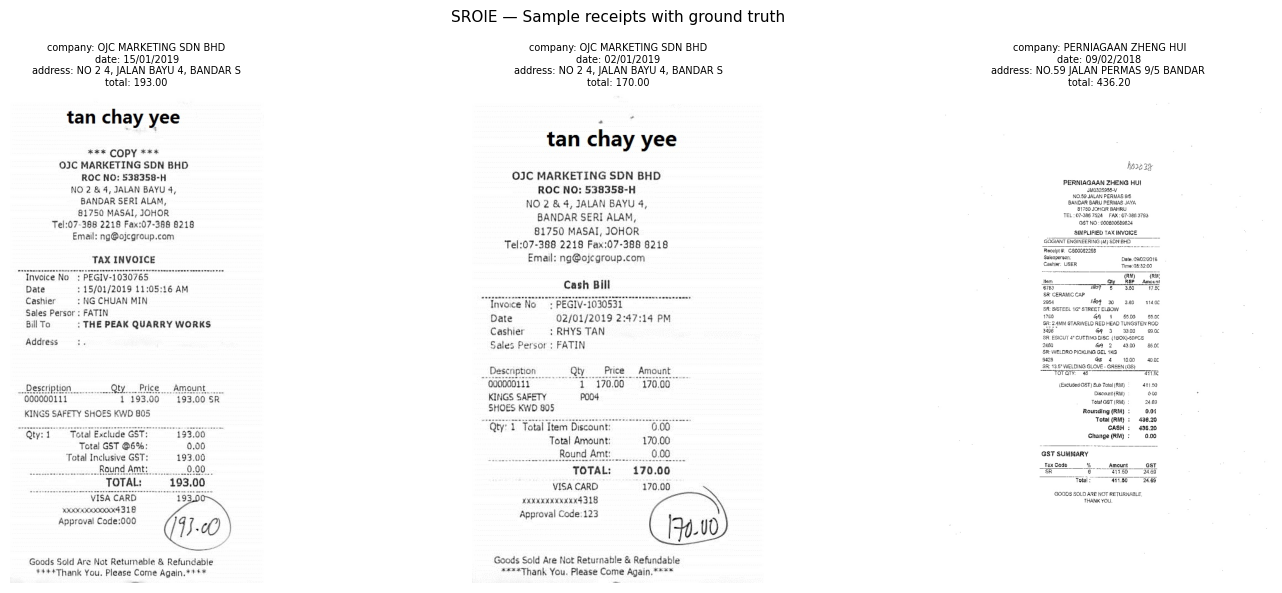

In [9]:
# Preview campioni
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, idx in zip(axes, [0, 1, 2]):
    ax.imshow(load_image(image_paths[idx]))
    title = "\n".join([f"{f}: {golds[idx][f][:30]}" for f in FIELDS])
    ax.set_title(title, fontsize=7)
    ax.axis("off")
plt.suptitle("SROIE — Sample receipts with ground truth", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sroie_samples.png"), dpi=120, bbox_inches="tight")
plt.show()

## Model 0 — Baseline (Tesseract OCR + regex)

In [10]:
def ocr_text(img: Image.Image) -> str:
    """Run Tesseract OCR on a PIL image and return raw text."""
    return pytesseract.image_to_string(img, config="--psm 6")


def regex_extract(text: str) -> dict:
    """
    Extract fields from raw OCR text using heuristic patterns.
    Returns dict with keys: company, date, address, total.
    """
    lines = [l.strip() for l in text.splitlines() if l.strip()]

    # ── TOTAL: look for currency patterns ────────────────────────────────
    total = ""
    total_patterns = [
        r'(?:TOTAL|GRAND TOTAL|AMOUNT DUE|TOTAL AMOUNT)[^\d]*(\d[\d,\.]+)',
        r'(?:RM|MYR|\$|USD)\s*(\d[\d,\.]+)',
        r'(\d{1,4}[\.,]\d{2})\s*$',
    ]
    for pat in total_patterns:
        m = re.search(pat, text, re.IGNORECASE)
        if m:
            total = m.group(1).strip()
            break

    # ── DATE: common date formats ─────────────────────────────────────────
    date = ""
    date_patterns = [
        r'(\d{1,2}[/-]\d{1,2}[/-]\d{2,4})',
        r'(\d{1,2}\s+(?:JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)[A-Z]*\.?\s+\d{2,4})',
        r'((?:JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)[A-Z]*\.?\s+\d{1,2},?\s+\d{4})',
    ]
    for pat in date_patterns:
        m = re.search(pat, text, re.IGNORECASE)
        if m:
            date = m.group(1).strip()
            break

    # ── COMPANY: first non-empty line (heuristic) ─────────────────────────
    company = lines[0] if lines else ""

    # ── ADDRESS: lines containing address keywords or numbers ─────────────
    address_lines = []
    address_keywords = re.compile(
        r'(?:jalan|lot|no\.?|block|floor|level|street|road|avenue|blvd|'
        r'mall|plaza|tower|building|taman|tesco|mydin|\d{5})',
        re.IGNORECASE
    )
    for line in lines[1:6]:  # search in first 6 lines after company
        if address_keywords.search(line):
            address_lines.append(line)
    address = " ".join(address_lines[:2]) if address_lines else ""

    return {"company": company, "date": date, "address": address, "total": total}


print('Baseline functions defined.')

Baseline functions defined.


In [11]:
import json, os

print('Running Tesseract OCR + regex baseline...')
baseline_preds = []
for i, img in ((i, load_image(p)) for i, p in enumerate(image_paths)):
    try:
        text = ocr_text(img)
    except pytesseract.TesseractNotFoundError:
        if i == 0:
            print("⚠️ Tesseract not found")
        text = ""
    pred = regex_extract(text)
    baseline_preds.append(pred)
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(image_paths)}')
print('\nDone.')

baseline_results = evaluate("Baseline (OCR + regex)", baseline_preds, golds)

# Save to disk
out = {
    "predictions": baseline_preds,
    "results":     baseline_results,
}
os.makedirs("/kaggle/working", exist_ok=True)
with open("/kaggle/working/baseline_results.json", "w") as f:
    json.dump(out, f, indent=2)

print("Saved to /kaggle/working/baseline_results.json")

Running baseline (OCR + regex)...
  50/347
  100/347
  150/347
  200/347
  250/347
  300/347

Done.

  Baseline (OCR + regex)
  Field              EM   Token F1   Char F1
  ---------------------------------------------
  company         0.112      0.272     0.454
  date            0.700      0.702     0.821
  address         0.063      0.500     0.631
  total           0.288      0.288     0.622
  ---------------------------------------------
  OVERALL         0.291      0.441     0.632
Salvato in /kaggle/working/baseline_results.json


## Model 1 — Qwen2-VL-7B
Prompt-based extraction using a zero/few-shot JSON output instruction.
Prompt-based extraction using a zero/few-shot JSON output instruction.


In [12]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

# Check available GPU memory
for i in range(torch.cuda.device_count()):
    free, total = torch.cuda.mem_get_info(i)
    print(f"GPU {i}: {free/1e9:.1f} GB free / {total/1e9:.1f} GB total")

GPU 0: 15.5 GB free / 15.6 GB total
GPU 1: 15.5 GB free / 15.6 GB total


In [13]:
import gc
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4'
)

qwen = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-7B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
)
qproc = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-7B-Instruct")
print('Qwen2-VL-7B loaded.')

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen2-VL-7B loaded.


In [14]:
def _resize(img: Image.Image, max_size: int = 512) -> Image.Image:
    """Downscale image to fit within max_size on longest edge."""
    w, h = img.size
    if max(w, h) > max_size:
        scale = max_size / max(w, h)
        return img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    return img


def _build_few_shot_json_block() -> str:
    """Return a text block showing the 10 labelled examples as JSON answers."""
    lines = []
    for k, (_, g) in enumerate(FEW_SHOT_EXAMPLES):
        answer = json.dumps(
            {f: g[f] for f in FIELDS}, ensure_ascii=False
        )
        lines.append(f"Example {k+1} answer: {answer}")
    return "\n".join(lines)


def qwen_extract(model, processor, img: Image.Image) -> dict:
    """Few-shot extraction with Qwen2/2.5-VL.

    The conversation starts with N_SHOTS (image, JSON-answer) pairs from the
    train split, followed by the query image.  This is a true multimodal
    few-shot prompt: the model sees real receipt images plus their labels.
    """
    img = _resize(img, max_size=512)

    # ── System instruction (task description) ────────────────────────────
    system_text = (
        "You are an expert invoice parser. "
        "Given a receipt image extract exactly four fields: "
        "company (business name), date (transaction date), "
        "address (store address), total (final amount paid). "
        "Reply ONLY with a valid JSON object with these exact keys. "
        "Use empty string for missing fields. No explanation."
    )

    # ── Few-shot turns: (user: image, assistant: JSON) x N_SHOTS ─────────
    messages = []
    for ex_img, ex_gold in FEW_SHOT_EXAMPLES:
        ex_img_small = _resize(ex_img, max_size=512)
        messages.append({"role": "user", "content": [
            {"type": "image", "image": ex_img_small},
            {"type": "text",  "text": system_text},
        ]})
        answer_json = json.dumps({f: ex_gold[f] for f in FIELDS}, ensure_ascii=False)
        messages.append({"role": "assistant", "content": answer_json})

    # ── Query turn ────────────────────────────────────────────────────────
    messages.append({"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text": system_text},
    ]})

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text], images=image_inputs, videos=video_inputs,
        padding=True, return_tensors="pt",
    )
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        ids = model.generate(**inputs, max_new_tokens=150, do_sample=False)
    input_len = inputs["input_ids"].shape[-1]
    raw = processor.decode(ids[0][input_len:], skip_special_tokens=True).strip()
    return parse_json_output(raw)


print('Running Qwen2-VL-7B extraction (few-shot, 10 train examples)...')
dump_fewshot_examples('qwen2-vl-7b', FEW_SHOT_EXAMPLES)
qwen_preds = []
for i, img in ((i, load_image(p)) for i, p in enumerate(image_paths)):
    pred = qwen_extract(qwen, qproc, img)
    qwen_preds.append(pred)
    torch.cuda.empty_cache()
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(image_paths)}')
        import pickle
        with open("/kaggle/working/qwen_checkpoint.pkl", "wb") as f:
            pickle.dump(qwen_preds, f)

print('\nDone.')
qwen_results = evaluate("Qwen2-VL-7B", qwen_preds, golds)
with open("/kaggle/working/qwen_results.json", "w") as f:
    json.dump({"predictions": qwen_preds, "results": qwen_results}, f, indent=2)
print("Saved to /kaggle/working/qwen_results.json")
free_memory(qwen, qproc)


Running Qwen2-VL-7B extraction (few-shot, 10 train examples)...
  💾 Saved 10 few-shot images to /kaggle/working/fewshot_examples/qwen2-vl-7b


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  50/347
  100/347
  150/347
  200/347
  250/347
  300/347

Done.

  Qwen2-VL-7B
  Field              EM   Token F1   Char F1
  ---------------------------------------------
  company         0.568      0.829     0.934
  date            0.571      0.577     0.888
  address         0.199      0.712     0.881
  total           0.666      0.666     0.849
  ---------------------------------------------
  OVERALL         0.501      0.696     0.888
Salvato in /kaggle/working/qwen_results.json
Memory freed.


## Model 2 — Qwen2.5-VL-3B
Same extraction prompt as Qwen2-VL-7B, using the smaller 3B variant.
Same extraction prompt as Qwen2-VL-7B, using the smaller 3B variant.


In [15]:
gc.collect()
torch.cuda.empty_cache()

from transformers import Qwen2_5_VLForConditionalGeneration

qwen2b = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    max_memory={0: "14GiB", 1: "0GiB"},
    low_cpu_mem_usage=True,
)
qproc2b = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct")
print('Qwen2.5-VL-3B loaded.')


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen2.5-VL-3B loaded.


In [16]:
print('Running Qwen2.5-VL-3B extraction (few-shot, 10 train examples)...')
dump_fewshot_examples('qwen2.5-vl-3b', FEW_SHOT_EXAMPLES)
qwen2b_preds = []
for i, img in ((i, load_image(p)) for i, p in enumerate(image_paths)):
    pred = qwen_extract(qwen2b, qproc2b, img)
    qwen2b_preds.append(pred)
    torch.cuda.empty_cache()
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(image_paths)}')
        import pickle
        with open("/kaggle/working/qwen2b_checkpoint.pkl", "wb") as f:
            pickle.dump(qwen2b_preds, f)

print('\nDone.')
qwen2b_results = evaluate("Qwen2.5-VL-3B", qwen2b_preds, golds)
import json
with open("/kaggle/working/qwen2b_results.json", "w") as f:
    json.dump({"predictions": qwen2b_preds, "results": qwen2b_results}, f, indent=2)
print("Saved to /kaggle/working/qwen2b_results.json")
free_memory(qwen2b, qproc2b)


Running Qwen2.5-VL-3B extraction (few-shot, 10 train examples)...
  💾 Saved 10 few-shot images to /kaggle/working/fewshot_examples/qwen2.5-vl-3b


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  50/347
  100/347
  150/347
  200/347
  250/347
  300/347

Done.

  Qwen2.5-VL-3B
  Field              EM   Token F1   Char F1
  ---------------------------------------------
  company         0.386      0.666     0.803
  date            0.323      0.323     0.768
  address         0.084      0.481     0.715
  total           0.452      0.452     0.716
  ---------------------------------------------
  OVERALL         0.311      0.481     0.750
Salvato in /kaggle/working/qwen2b_results.json
Memory freed.


## Model 3 — PaliGemma2-3B
Single-turn extraction using field-by-field prompting (PaliGemma does not support multi-turn).
Single-turn extraction using field-by-field prompting (PaliGemma does not support multi-turn).


In [17]:
from transformers import PaliGemmaForConditionalGeneration, AutoProcessor as PaliProcessor

pali = PaliGemmaForConditionalGeneration.from_pretrained(
    "google/paligemma2-3b-mix-448",
    torch_dtype=torch.float16,
    device_map="auto",
    max_memory={0: "0GiB", 1: "14GiB"},
).eval()
pproc = PaliProcessor.from_pretrained("google/paligemma2-3b-mix-448")
print('PaliGemma2-3B loaded.')

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

...

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

PaliGemma2-3B loaded.


In [18]:
def paligemma_extract(model, processor, img: Image.Image) -> dict:
    """Few-shot extraction with PaliGemma2-3B.

    PaliGemma uses a single-turn format.  We embed the 10 labelled train
    examples as a structured text block inside the prompt, followed by
    per-field questions.  (PaliGemma does not support multi-image turns,
    so we inject the ground-truth answers as text rather than images.)
    """
    few_shot_block = _build_few_shot_json_block()

    fields = {
        "company": (
            f"<image>Below are {N_SHOTS} example receipts with their extracted fields:\n"
            f"{few_shot_block}\n\n"
            "Now, given the receipt image above, what is the store or company name?"
        ),
        "date": (
            f"<image>Below are {N_SHOTS} example receipts with their extracted fields:\n"
            f"{few_shot_block}\n\n"
            "Now, given the receipt image above, what is the transaction date?"
        ),
        "address": (
            f"<image>Below are {N_SHOTS} example receipts with their extracted fields:\n"
            f"{few_shot_block}\n\n"
            "Now, given the receipt image above, what is the store address?"
        ),
        "total": (
            f"<image>Below are {N_SHOTS} example receipts with their extracted fields:\n"
            f"{few_shot_block}\n\n"
            "Now, given the receipt image above, what is the total amount paid?"
        ),
    }
    result = {}
    device = next(model.parameters()).device
    for field, prompt in fields.items():
        inputs = processor(text=prompt, images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            ids = model.generate(**inputs, max_new_tokens=60, do_sample=False)
        input_len = inputs["input_ids"].shape[-1]
        raw = processor.decode(ids[0][input_len:], skip_special_tokens=True).strip()
        result[field] = raw
    return result


In [19]:
print('Running PaliGemma2-3B extraction...')
dump_fewshot_examples('paligemma2-3b', FEW_SHOT_EXAMPLES)
pali_preds = []
for i, img in ((i, load_image(p)) for i, p in enumerate(image_paths)):
    pred = paligemma_extract(pali, pproc, img)
    pali_preds.append(pred)
    torch.cuda.empty_cache()
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(image_paths)}')

print('\nDone.')
pali_results = evaluate("PaliGemma2-3B", pali_preds, golds)
free_memory(pali, pproc)

Running PaliGemma2-3B extraction...
  💾 Saved 10 few-shot images to /kaggle/working/fewshot_examples/paligemma2-3b
  50/347
  100/347
  150/347
  200/347
  250/347
  300/347

Done.

  PaliGemma2-3B
  Field              EM   Token F1   Char F1
  ---------------------------------------------
  company         0.014      0.169     0.579
  date            0.032      0.032     0.675
  address         0.000      0.136     0.646
  total           0.262      0.262     0.668
  ---------------------------------------------
  OVERALL         0.077      0.150     0.642
Memory freed.


In [20]:
import json
with open("/kaggle/working/pali_results.json", "w") as f:
    json.dump({
        "predictions": pali_preds,
        "results": pali_results
    }, f, indent=2)
print("Saved to /kaggle/working/pali_results.json")

Salvato in /kaggle/working/pali_results.json


In [21]:
# NOTE: this debug cell is disabled because pali has already been
# freed via free_memory() in the previous cell.
# To debug PaliGemma, move this block BEFORE the free_memory() call.
print("PaliGemma debug skipped (model already freed from memory).")


Debug PaliGemma saltato (modello già liberato dalla memoria).


## Model 4 — SmolVLM-500M
Extraction using instruction-tuned SmolVLM. Context window is limited to 8192 tokens.
Extraction using instruction-tuned SmolVLM. Context window is limited to 8192 tokens.


In [22]:
import gc
import torch

# Aggressive memory cleanup to avoid OOM after PaliGemma
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
for i in range(torch.cuda.device_count()):
    free, total = torch.cuda.mem_get_info(i)
    print(f"  GPU {i}: {free/1e9:.1f} GB free / {total/1e9:.1f} GB total")

from transformers import AutoProcessor, Idefics3ForConditionalGeneration

smol = Idefics3ForConditionalGeneration.from_pretrained(
    "HuggingFaceTB/SmolVLM-500M-Instruct",
    torch_dtype=torch.float16,
    device_map="auto",
    max_memory={0: "0GiB", 1: "14GiB"},
).eval()
sproc = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct")
print("SmolVLM-500M loaded.")


  GPU 0: 11.2 GB free / 15.6 GB total
  GPU 1: 5.0 GB free / 15.6 GB total


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

SmolVLM-500M loaded.


In [23]:
# SmolVLM-500M has a context window of 8192 tokens: with 10 few-shot examples
# the prompt exceeds this limit (8281 > 8192), causing OOM on 16GB GPU.
# We cap at 4 examples to stay within the token budget.
SMOL_N_SHOTS = 4
SMOL_FEW_SHOT_EXAMPLES = FEW_SHOT_EXAMPLES[:SMOL_N_SHOTS]
print(f"SmolVLM will use {len(SMOL_FEW_SHOT_EXAMPLES)} few-shot examples (capped from {len(FEW_SHOT_EXAMPLES)}).")


def smolvlm_extract(model, processor, img: Image.Image) -> dict:
    """Few-shot extraction with SmolVLM-500M.

    SmolVLM supports multi-image chat turns.  We build a conversation with
    SMOL_N_SHOTS (image → JSON) pairs from the train split, then append the
    query image.  The model is expected to reproduce the JSON pattern.
    Capped at 4 examples to fit within the 8192-token context window.
    """
    # ── Few-shot turns ────────────────────────────────────────────────────
    messages = []
    for ex_img, ex_gold in SMOL_FEW_SHOT_EXAMPLES:
        ex_img_small = _resize(ex_img, max_size=512)
        messages.append({"role": "user", "content": [
            {"type": "image"},
            {"type": "text",  "text": (
                "Extract company, date, address, total from this receipt. "
                "Reply ONLY with a JSON object with those exact keys."
            )},
        ]})
        answer_json = json.dumps({f: ex_gold[f] for f in FIELDS}, ensure_ascii=False)
        messages.append({"role": "assistant", "content": answer_json})

    # ── Query turn ────────────────────────────────────────────────────────
    messages.append({"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": (
            "Extract company, date, address, total from this receipt. "
            "Reply ONLY with a JSON object with those exact keys."
        )},
    ]})

    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
    # Collect all images in order: SMOL_N_SHOTS examples + 1 query
    all_images = [_resize(ex_img, max_size=512) for ex_img, _ in SMOL_FEW_SHOT_EXAMPLES] + [_resize(img, max_size=512)]
    inputs = processor(text=prompt, images=all_images, return_tensors="pt")
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        ids = model.generate(**inputs, max_new_tokens=200, do_sample=False)
    input_len = inputs["input_ids"].shape[-1]
    raw = processor.decode(ids[0][input_len:], skip_special_tokens=True).strip()
    return parse_json_output(raw)


SmolVLM will use 4 few-shot examples (capped from 10).


In [24]:
print('Running SmolVLM-500M extraction...')
dump_fewshot_examples('smolvlm-500m', SMOL_FEW_SHOT_EXAMPLES)
smol_preds = []
for i, img in ((i, load_image(p)) for i, p in enumerate(image_paths)):
    pred = smolvlm_extract(smol, sproc, img)
    smol_preds.append(pred)
    torch.cuda.empty_cache()
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(image_paths)}')

print('\nDone.')
smol_results = evaluate("SmolVLM-500M", smol_preds, golds)
free_memory(smol, sproc)
# Final checkpoint save
import json
with open("/kaggle/working/smol_results.json", "w") as f:
    json.dump({
        "predictions": smol_preds,
        "results": smol_results
    }, f, indent=2)
print("Saved to /kaggle/working/smol_results.json")

Running SmolVLM-500M extraction...
  💾 Saved 4 few-shot images to /kaggle/working/fewshot_examples/smolvlm-500m
  50/347
  100/347
  150/347
  200/347
  250/347
  300/347

Done.

  SmolVLM-500M
  Field              EM   Token F1   Char F1
  ---------------------------------------------
  company         0.000      0.000     0.000
  date            0.000      0.000     0.000
  address         0.000      0.000     0.000
  total           0.000      0.000     0.000
  ---------------------------------------------
  OVERALL         0.000      0.000     0.000
Memory freed.
Salvato in /kaggle/working/smol_results.json


## 4 — Comparison & visualisation

In [25]:
import os, pickle, json

CHECKPOINT_PATH = "/kaggle/working/checkpoint.pkl"

if os.path.exists(CHECKPOINT_PATH):
    print("Loading from checkpoint...")
    with open(CHECKPOINT_PATH, "rb") as f:
        ck = pickle.load(f)
    baseline_preds = ck.get("baseline_preds", baseline_preds)
    smol_preds     = ck.get("smol_preds", smol_preds)
    pali_preds     = ck.get("pali_preds", pali_preds)
    golds          = ck.get("golds", golds)
    RESULTS        = ck.get("RESULTS", RESULTS)
    print(f"Available models: {list(RESULTS.keys())}")
else:
    print("No checkpoint found, using in-memory variables.")

# Load qwen_preds and qwen2b_preds from separate files if they exist
for fname, varname in [
    ("/kaggle/working/qwen_results.json",   "qwen_preds"),
    ("/kaggle/working/qwen2b_results.json",  "qwen2b_preds"),
    ("/kaggle/working/pali_results.json",    "pali_preds"),
    ("/kaggle/working/smol_results.json",    "smol_preds"),
]:
    if os.path.exists(fname):
        with open(fname) as f:
            data = json.load(f)
        if varname == "qwen_preds":   qwen_preds   = data["predictions"]
        elif varname == "qwen2b_preds": qwen2b_preds = data["predictions"]
        elif varname == "pali_preds":  pali_preds   = data["predictions"]
        elif varname == "smol_preds":  smol_preds   = data["predictions"]

# Model order in plots: Baseline, Qwen7B, Qwen2B, PaliGemma, SmolVLM
all_preds = {
    "Baseline (OCR + regex)": baseline_preds,
    "Qwen2-VL-7B":            qwen_preds,
    "Qwen2.5-VL-3B":          qwen2b_preds,
    "PaliGemma2-3B":          pali_preds,
    "SmolVLM-500M":           smol_preds,
}
for model_name, preds in all_preds.items():
    if model_name not in RESULTS and preds is not None:
        print(f"Ricalcolando {model_name}...")
        evaluate(model_name, preds, golds)

# Summary table — all 3 metrics
rows = []
for model_name, res in RESULTS.items():
    row = {"Model": model_name}
    row.update(res)
    rows.append(row)

df = pd.DataFrame(rows).set_index("Model")
print("\nExtraction Results — Summary (EM / Token F1 / Char F1)")
print("=" * 70)
print(df.to_string())
df.to_csv(os.path.join(OUTPUT_DIR, "03_extraction_results.csv"))
print(f"\nSaved -> {OUTPUT_DIR}/03_extraction_results.csv")


Nessun checkpoint trovato, uso variabili in memoria.

Extraction Results — Summary (EM / Token F1 / Char F1)
                        em_company  tf1_company  cf1_company  em_date  tf1_date  cf1_date  em_address  tf1_address  cf1_address  em_total  tf1_total  cf1_total  em_overall  tf1_overall  cf1_overall
Model                                                                                                                                                                                                
Baseline (OCR + regex)       0.112        0.272        0.454    0.700     0.702     0.821       0.063        0.500        0.631     0.288      0.288      0.622       0.291        0.441        0.632
Qwen2-VL-7B                  0.568        0.829        0.934    0.571     0.577     0.888       0.199        0.712        0.881     0.666      0.666      0.849       0.501        0.696        0.888
Qwen2.5-VL-3B                0.386        0.666        0.803    0.323     0.323     0.768       0.0

In [26]:
# Compact table: best metric per field (total=EM, company/date=TokenF1, address=CharF1)
print("\nFew-Shot — Main metric per field (total=EM, company/date=TokenF1, address=CharF1)")
print("=" * 72)
header = f"{'Model':<28}  {'company(tf1)':>13}  {'date(tf1)':>10}  {'address(cf1)':>13}  {'total(em)':>10}"
print(header)
print("─" * 72)
for model_name, res in RESULTS.items():
    row = (
        f"{model_name:<28}  "
        f"{res['tf1_company']:>13.3f}  "
        f"{res['tf1_date']:>10.3f}  "
        f"{res['cf1_address']:>13.3f}  "
        f"{res['em_total']:>10.3f}"
    )
    print(row)



Few-Shot — Metrica principale per campo (total=EM, company/date=TokenF1, address=CharF1)
Model                          company(tf1)   date(tf1)   address(cf1)   total(em)
────────────────────────────────────────────────────────────────────────
Baseline (OCR + regex)                0.272       0.702          0.631       0.288
Qwen2-VL-7B                           0.829       0.577          0.881       0.666
Qwen2.5-VL-3B                         0.666       0.323          0.715       0.452
PaliGemma2-3B                         0.169       0.032          0.646       0.262
SmolVLM-500M                          0.000       0.000          0.000       0.000


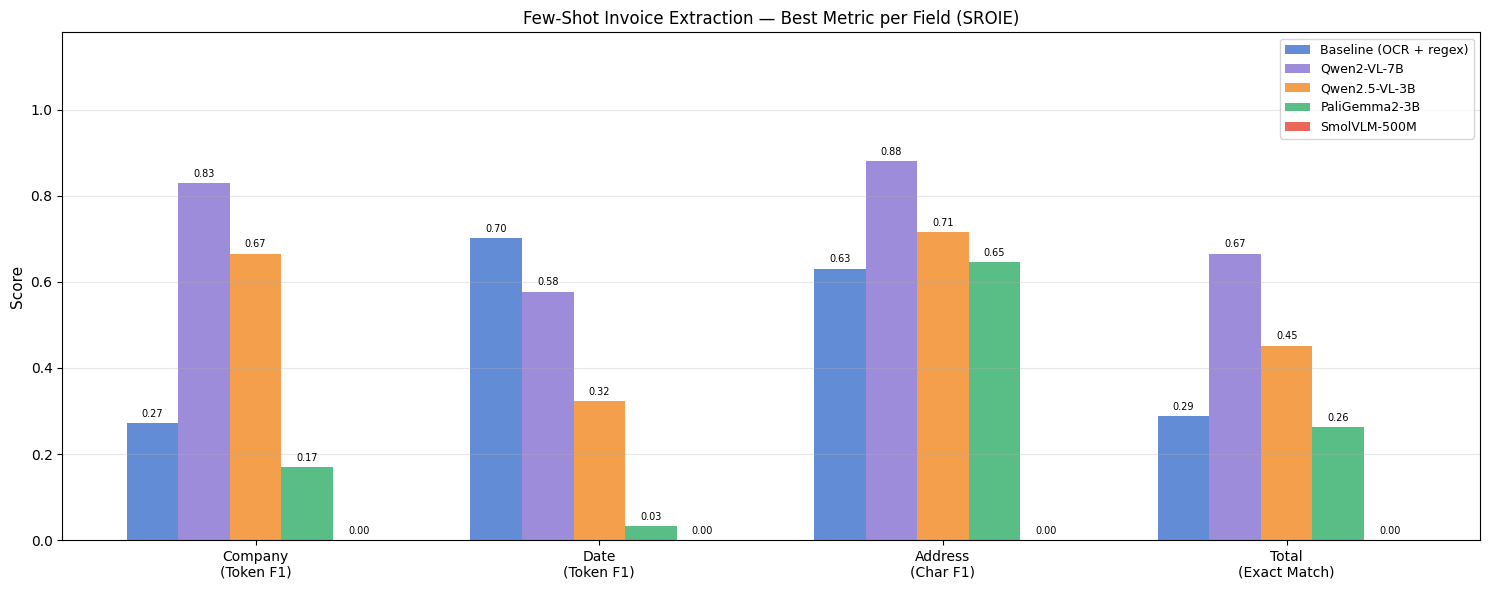

Saved → /kaggle/working/outputs/03_extraction_comparison.png


In [27]:
# Per-field bar chart using the most appropriate metric for each field
models = list(RESULTS.keys())
colors = ["#4878CF", "#8B78D4", "#F28E2B", "#3CB371", "#e74c3c"]

# (field, metric_key, label)
field_metrics = [
    ("company", "tf1_company", "Company\n(Token F1)"),
    ("date",    "tf1_date",    "Date\n(Token F1)"),
    ("address", "cf1_address", "Address\n(Char F1)"),
    ("total",   "em_total",    "Total\n(Exact Match)"),
]

x = np.arange(len(field_metrics))
width = 0.15

fig, ax = plt.subplots(figsize=(15, 6))
for i, (model_name, color) in enumerate(zip(models, colors)):
    vals = [RESULTS[model_name][mk] for _, mk, _ in field_metrics]
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels([lbl for _, _, lbl in field_metrics], fontsize=10)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_title("Few-Shot Invoice Extraction — Best Metric per Field (SROIE)", fontsize=12)
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "03_extraction_comparison.png")
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")


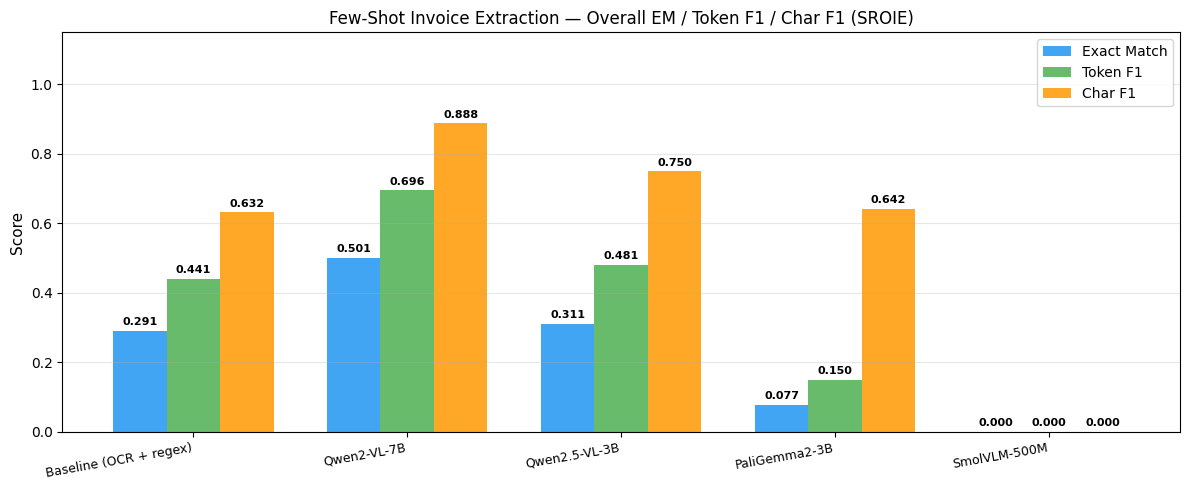

Saved → /kaggle/working/outputs/03_overall_metrics.png


In [28]:
# Overall bar chart — EM vs Token F1 vs Char F1 (all fields combined) (all fields combined)
models = list(RESULTS.keys())
colors = ["#4878CF", "#8B78D4", "#F28E2B", "#3CB371", "#e74c3c"]

metric_keys   = ["em_overall", "tf1_overall", "cf1_overall"]
metric_labels = ["Exact Match", "Token F1", "Char F1"]
metric_colors = ["#2196F3", "#4CAF50", "#FF9800"]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for j, (mk, ml, mc) in enumerate(zip(metric_keys, metric_labels, metric_colors)):
    vals = [RESULTS[m][mk] for m in models]
    bars = ax.bar(x + j * width, vals, width, label=ml, color=mc, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels(models, fontsize=9, rotation=10, ha="right")
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title("Few-Shot Invoice Extraction — Overall EM / Token F1 / Char F1 (SROIE)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "03_overall_metrics.png")
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")


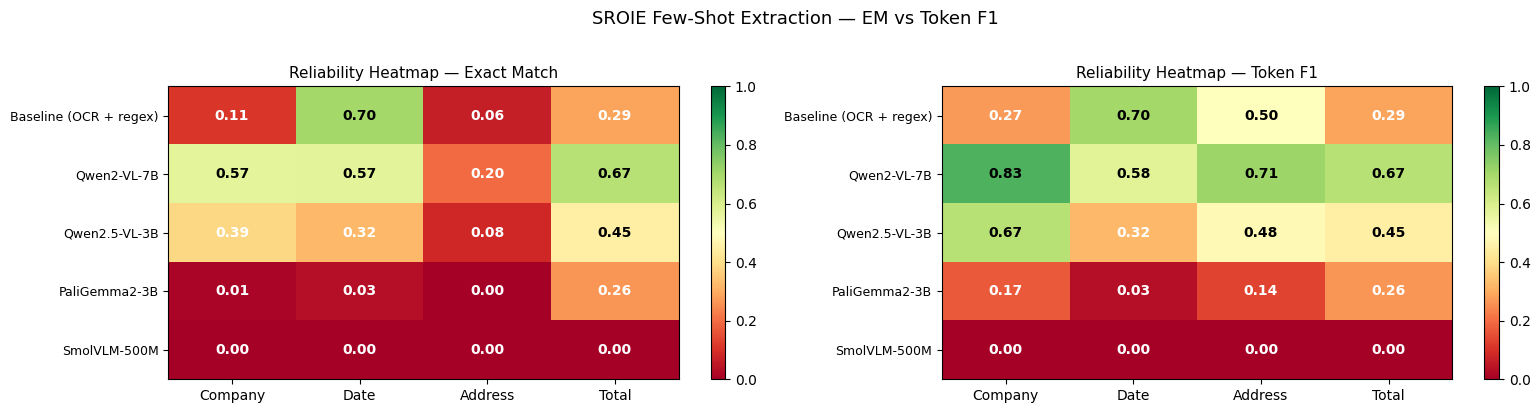

Saved → /kaggle/working/outputs/03_reliability_heatmap.png


In [29]:
# Dual heatmap: Exact Match (left) vs Token F1 (right)
models = list(RESULTS.keys())
em_matrix  = np.array([[RESULTS[m][f"em_{f}"]  for f in FIELDS] for m in models])
tf1_matrix = np.array([[RESULTS[m][f"tf1_{f}"] for f in FIELDS] for m in models])

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, matrix, title in zip(
    axes,
    [em_matrix, tf1_matrix],
    ["Exact Match", "Token F1"]
):
    im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(FIELDS)))
    ax.set_xticklabels([f.capitalize() for f in FIELDS], fontsize=10)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=9)
    for i in range(len(models)):
        for j in range(len(FIELDS)):
            v = matrix[i, j]
            color = "white" if v < 0.4 or v > 0.85 else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=10, color=color, fontweight="bold")
    plt.colorbar(im, ax=ax)
    ax.set_title(f"Reliability Heatmap — {title}", fontsize=11)

plt.suptitle("SROIE Few-Shot Extraction — EM vs Token F1", fontsize=13, y=1.02)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "03_reliability_heatmap.png")
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {path}")


In [30]:
# Error analysis: inspect failure cases: inspect failure cases
all_preds = {
    "Baseline (OCR + regex)": baseline_preds,
    "Qwen2-VL-7B":            qwen_preds,
    "Qwen2.5-VL-3B":          qwen2b_preds,
    "PaliGemma2-3B":          pali_preds,
    "SmolVLM-500M":           smol_preds,
}

def error_analysis(model_name: str, preds: list, golds: list, field: str, n: int = 5):
    failures = [
        (i, preds[i].get(field, ''), golds[i][field])
        for i in range(len(golds))
        if get_normalised(field, preds[i].get(field, '')) != get_normalised(field, golds[i][field])
    ]
    print(f"\n{model_name} -- '{field}' failures ({len(failures)}/{len(golds)})")
    print('-' * 60)
    for idx, pred, gold in failures[:n]:
        tf1 = token_f1(pred, gold, field)
        cf1 = char_f1(pred, gold, field)
        print(f"  Sample {idx:3d}  PRED: '{pred[:40]}'")
        print(f"             GOLD: '{gold[:40]}'  [tf1={tf1:.2f} cf1={cf1:.2f}]")

best_model  = max(RESULTS, key=lambda m: RESULTS[m]["em_total"])
worst_model = min(RESULTS, key=lambda m: RESULTS[m]["em_total"])
for model in [best_model, worst_model]:
    error_analysis(model, all_preds[model], golds, "total", n=5)



Qwen2-VL-7B -- 'total' failures (116/347)
------------------------------------------------------------
  Sample   2  PRED: '26.60'
             GOLD: '436.20'  [tf1=0.00 cf1=0.73]
  Sample  10  PRED: '160.17'
             GOLD: '169.80'  [tf1=0.00 cf1=0.67]
  Sample  20  PRED: '10.00'
             GOLD: '$8.20'  [tf1=0.00 cf1=0.44]
  Sample  21  PRED: '1.40'
             GOLD: '$8.20'  [tf1=0.00 cf1=0.50]
  Sample  25  PRED: '1.46'
             GOLD: '$8.20'  [tf1=0.00 cf1=0.25]

SmolVLM-500M -- 'total' failures (347/347)
------------------------------------------------------------
  Sample   0  PRED: ''
             GOLD: '193.00'  [tf1=0.00 cf1=0.00]
  Sample   1  PRED: ''
             GOLD: '170.00'  [tf1=0.00 cf1=0.00]
  Sample   2  PRED: ''
             GOLD: '436.20'  [tf1=0.00 cf1=0.00]
  Sample   3  PRED: ''
             GOLD: '4.90'  [tf1=0.00 cf1=0.00]
  Sample   4  PRED: ''
             GOLD: '38.90'  [tf1=0.00 cf1=0.00]


In [31]:
# Final summary — all 3 metrics
print("\nFew-Shot Invoice Extraction — Final Results (SROIE) [10 train examples]")
print("=" * 80)
print(f"  {'Model':<28}  {'EM':>6}  {'TokenF1':>8}  {'CharF1':>7}  (overall)")
print("─" * 80)
for model_name, res in RESULTS.items():
    print(
        f"  {model_name:<28}  "
        f"{res['em_overall']:>6.3f}  "
        f"{res['tf1_overall']:>8.3f}  "
        f"{res['cf1_overall']:>7.3f}"
    )

print()
best_em  = max(RESULTS, key=lambda m: RESULTS[m]["em_overall"])
best_tf1 = max(RESULTS, key=lambda m: RESULTS[m]["tf1_overall"])
hardest_em  = min(FIELDS, key=lambda f: np.mean([RESULTS[m][f"em_{f}"]  for m in RESULTS]))
hardest_tf1 = min(FIELDS, key=lambda f: np.mean([RESULTS[m][f"tf1_{f}"] for m in RESULTS]))

print(f"  • Best overall (EM):      {best_em}  ({RESULTS[best_em]['em_overall']:.3f})")
print(f"  • Best overall (TokenF1): {best_tf1}  ({RESULTS[best_tf1]['tf1_overall']:.3f})")
print(f"  • Hardest field (EM):     '{hardest_em}'")
print(f"  • Hardest field (TokenF1):'{hardest_tf1}'")
print()
print("Note: EM is optimal for 'total'; Token F1 for 'company' and 'date';")
print("      Char F1 for 'address' (robust to abbreviations and OCR typos).")



Few-Shot Invoice Extraction — Final Results (SROIE) [10 train examples]
  Model                             EM   TokenF1   CharF1  (overall)
────────────────────────────────────────────────────────────────────────────────
  Baseline (OCR + regex)         0.291     0.441    0.632
  Qwen2-VL-7B                    0.501     0.696    0.888
  Qwen2.5-VL-3B                  0.311     0.481    0.750
  PaliGemma2-3B                  0.077     0.150    0.642
  SmolVLM-500M                   0.000     0.000    0.000

  • Best overall (EM):      Qwen2-VL-7B  (0.501)
  • Best overall (TokenF1): Qwen2-VL-7B  (0.696)
  • Hardest field (EM):     'address'
  • Hardest field (TokenF1):'date'

Nota: EM è ottimale per 'total'; Token F1 per 'company' e 'date';
      Char F1 per 'address' (robusta ad abbreviazioni e typo OCR).
